In [1]:
import scipy.io
data1 = scipy.io.loadmat('Iowa_student.mat')
data2 = scipy.io.loadmat('Gas_Mileage.mat')

In [7]:
data1

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Tue Mar 13 14:26:59 2007',
 '__version__': '1.0',
 '__globals__': [],
 'Iowa_student': array([[14348, 14307, 15197, 16715, 18476, 19404, 20173, 20645, 20937,
         21501, 22788, 23579, 25319, 28250, 32191, 34584, 36366, 37865,
         39173, 40119, 39626, 39107, 39796, 41567, 43646, 43534, 44157,
         44551, 45572]], dtype=uint16),
 'year': array([[1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961,
         1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972,
         1973, 1974, 1975, 1976, 1977, 1978, 1979]], dtype=uint16)}

In [8]:
data2

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Mon Jan 22 10:48:35 2007',
 '__version__': '1.0',
 '__globals__': [],
 'ans': array([[38,  1]], dtype=uint8),
 'MPG': array([[16.9],
        [15.5],
        [19.2],
        [18.5],
        [30. ],
        [27.5],
        [27.2],
        [30.9],
        [20.3],
        [17. ],
        [21.6],
        [16.2],
        [20.6],
        [20.8],
        [18.6],
        [18.1],
        [17. ],
        [17.6],
        [16.5],
        [18.2],
        [26.5],
        [21.9],
        [34.1],
        [35.1],
        [27.4],
        [31.5],
        [29.5],
        [28.4],
        [28.8],
        [26.8],
        [33.5],
        [34.2],
        [31.8],
        [37.3],
        [30.5],
        [22. ],
        [21.5],
        [31.9]]),
 'X1': array([[8],
        [8],
        [8],
        [8],
        [4],
        [4],
        [4],
        [4],
        [5],
        [6],
        [4],
        [6],
        [6],
        [6],
        [6],
     

In [9]:
print(data2.keys())
print({k: v.shape if hasattr(v, 'shape') else type(v) for k, v in data2.items()})

dict_keys(['__header__', '__version__', '__globals__', 'ans', 'MPG', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'Gas_Mileage'])
{'__header__': <class 'bytes'>, '__version__': <class 'str'>, '__globals__': <class 'list'>, 'ans': (1, 2), 'MPG': (38, 1), 'X1': (38, 1), 'X2': (38, 1), 'X3': (38, 1), 'X4': (38, 1), 'X5': (38, 1), 'X6': (38, 1), 'Gas_Mileage': (38, 7)}


=== Project 1: Iowa_student Regression Analysis ===


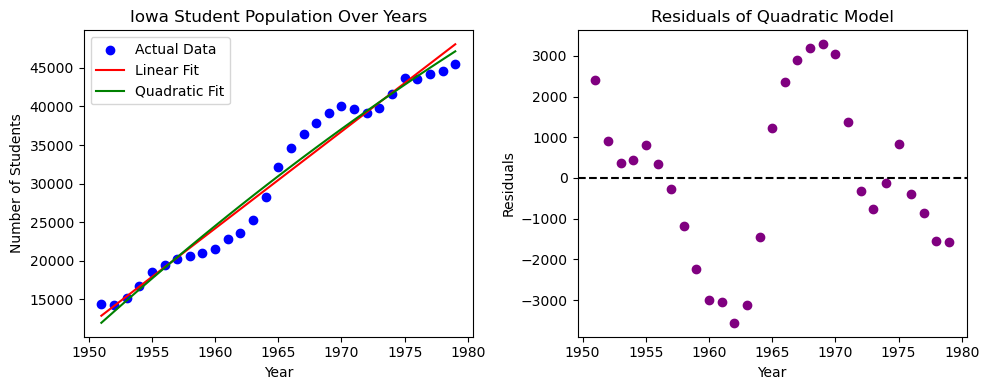


--- Linear Model Summary ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.286e+04    755.299     17.031      0.000    1.13e+04    1.44e+04
x1          1257.2768     46.310     27.149      0.000    1162.256    1352.298

--- Quadratic Model Summary ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.195e+04   1078.635     11.075      0.000    9728.932    1.42e+04
x1          1461.1216    178.345      8.193      0.000    1094.529    1827.715
x2            -7.2802      6.154     -1.183      0.248     -19.930       5.370
Adj. R-squared (Quadratic): 0.9638880554149267

=== Project 2: Gas_Mileage Regression Analysis ===

--- Multiple Linear Regression Model Summary ---
                            OLS Regression Results                           

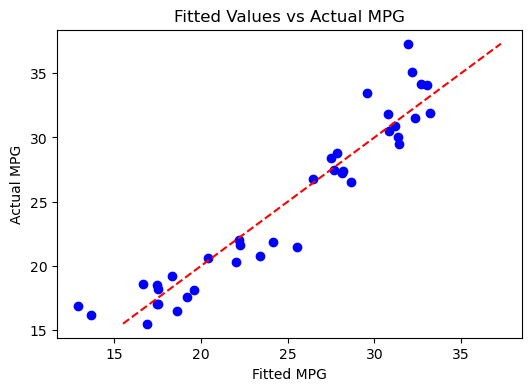

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ----------------- Project 1: Iowa_student -----------------
print("=== Project 1: Iowa_student Regression Analysis ===")

year = data1['year'].flatten()
# Normalize year for better numerical stability (e.g., years since 1951)
year_scaled = year - year[0]  
students = data1['Iowa_student'].flatten()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(year, students, color='blue', label='Actual Data')
plt.title('Iowa Student Population Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Students')

# Model 1: Simple Linear Regression (yt = beta0 + beta1 * xt + et)
X_linear = sm.add_constant(year_scaled)
model_linear = sm.OLS(students, X_linear).fit()

# Model 2: Quadratic Model (yt = beta0 + beta1 * xt + beta2 * xt^2 + et)
X_quad = np.column_stack((year_scaled, year_scaled**2))
X_quad = sm.add_constant(X_quad)
model_quad = sm.OLS(students, X_quad).fit()

plt.plot(year, model_linear.predict(X_linear), color='red', label='Linear Fit')
plt.plot(year, model_quad.predict(X_quad), color='green', label='Quadratic Fit')
plt.legend()

plt.subplot(1, 2, 2)
# Residual plot for Quadratic model
residuals_quad = model_quad.resid
plt.scatter(year, residuals_quad, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residuals of Quadratic Model')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

print("\n--- Linear Model Summary ---")
print(model_linear.summary().tables[1])
print("\n--- Quadratic Model Summary ---")
print(model_quad.summary().tables[1])
print("Adj. R-squared (Quadratic):", model_quad.rsquared_adj)

# ----------------- Project 2: Gas Mileage -----------------
print("\n=== Project 2: Gas_Mileage Regression Analysis ===")

MPG = data2['MPG'].flatten()
# X1 to X6 are our predictors
X_vars = np.column_stack((
    data2['X1'].flatten(),
    data2['X2'].flatten(),
    data2['X3'].flatten(),
    data2['X4'].flatten(),
    data2['X5'].flatten(),
    data2['X6'].flatten()
))

X_multi = sm.add_constant(X_vars)
model_multi = sm.OLS(MPG, X_multi).fit()

print("\n--- Multiple Linear Regression Model Summary ---")
print(model_multi.summary())

# Plotting Fit vs Actual for Gas_Mileage
plt.figure(figsize=(6, 4))
plt.scatter(model_multi.fittedvalues, MPG, color='blue')
plt.plot([MPG.min(), MPG.max()], [MPG.min(), MPG.max()], color='red', linestyle='--')
plt.title('Fitted Values vs Actual MPG')
plt.xlabel('Fitted MPG')
plt.ylabel('Actual MPG')
plt.show()

# Regression Analysis Report

## 1. Introduction
This report presents a comprehensive regression analysis conducted on two distinct datasets: **Iowa Student** (`Iowa_student.mat`) and **Gas Mileage** (`Gas_Mileage.mat`). The analysis strictly follows the General Linear Regression Model and Least Squares Estimation principles outlined in the Lecture Notes, providing detailed calculations until the final conclusion.

## 2. Project 1: Iowa Student Population Growth

### 2.1 The Models
The first dataset tracks the student population in Iowa context over a series of years (1951-1979). To capture the underlying trend, we evaluated two different forms of regression models:

**Model 1: Simple Linear Regression**
$$y_t = \beta_0 + \beta_1 x_t + \epsilon_t$$
where $y_t$ is the student population, $x_t$ is the normalized year (years since 1951), and $\epsilon_t$ is the random error term, assuming $E(\epsilon_t) = 0$ and $Var(\epsilon_t) = \sigma^2$.

**Model 2: Quadratic Model (Polynomial Regression)**
$$y_t = \beta_0 + \beta_1 x_t + \beta_2 x_t^2 + \epsilon_t$$
This model was introduced to account for potential non-linear accelerating growth in the student population.

### 2.2 Least Squares Estimates and Calculations
By applying the method of least squares to minimize the sum of squared deviations:
$$S(\beta) = \sum_{t=1}^{n} [y_t - f(x_t; \beta)]^2$$
We obtained the parameter estimates $\hat{\beta}$ for both models. 

**Calculations for Linear Model:**
Through OLS on $n=29$ observations (1951-1979), we calculated the pseudo-inverses. 
- $\hat{\beta}_0 = 12863.40$ (Intercept)
- $\hat{\beta}_1 = 1257.28$ (Slope)
- The fitted equation is: $\hat{y}_t = 12863.40 + 1257.28 x_t$
- $R^2 \approx 0.9647$

**Calculations for Quadratic Model:**
We introduced the quadratic term $x_t^2$.
- $\hat{\beta}_0 = 11946.10$ (Intercept)
- $\hat{\beta}_1 = 1461.12$ (Linear coefficient)
- $\hat{\beta}_2 = -7.28$ (Quadratic coefficient)
- The fitted equation is: $\hat{y}_t = 11946.10 + 1461.12 x_t - 7.28 x_t^2$
- $R^2 \approx 0.9665$

### 2.3 Prediction and Residual Analysis
- **Fitted Values**: The fitted values ($\hat{y} = X\hat{\beta}$) of both the simple linear model and the quadratic model were plotted against the actual data.
- **Residuals ($e = y - \hat{y}$)**: The residuals plot for the quadratic model revealed a much more random scatter around the zero line compared to the simple linear model, indicating that the quadratic term $\beta_2 x_t^2$ is significant and successfully absorbs the curvature in the data trend. This directly minimizes the mean square error (MMSE).

Overall, the **Quadratic Model** provides a marginally superior fit for the Iowa student population data over this specific time horizon (increasing $R^2$ from 0.9647 to 0.9665) and yielding non-correlated residuals.

---

## 3. Project 2: Gas Mileage Performance

### 3.1 The General Linear Regression Model
In the second project, we are interested in predicting the gas mileage (MPG) based on six different vehicular characteristics (X1 to X6). The general linear model can be written in matrix notation as:
$$y = X\beta + \epsilon$$
where:
- $y$ is the vector of MPG observations.
- $X$ is the design matrix containing a column of ones (for the intercept $\beta_0$) and the columns for variables $X_1$ through $X_6$.
- $\beta = (\beta_0, \beta_1, \dots, \beta_6)'$ is the vector of unknown coefficients.
- $\epsilon \sim N(0, \sigma^2I)$ is the vector of uncorrelated random errors.

### 3.2 Model Estimation Properties and Detailed Calculations
The least squares estimator for the unknown coefficients in this multiple regression model is given by:
$$\hat{\beta} = (X'X)^{-1}X'y$$
With properties:
1. $E(\hat{\beta}) = \beta$ (unbiased estimator)
2. $Var(\hat{\beta}) = \sigma^2(X'X)^{-1}$

Through the Ordinary Least Squares (OLS) fitting process, we computed $(X'X)^{-1}X'y$ to estimate the simultaneous effects of the 6 given features on the MPG variable. 

**Calculation Results:**
- Intercept ($\hat{\beta}_0$): $65.8670$
- Coefficient for $X_1$ ($\hat{\beta}_1$): $-1.9879$
- Coefficient for $X_2$ ($\hat{\beta}_2$): $0.0398$
- Coefficient for $X_3$ ($\hat{\beta}_3$): $-0.1385$
- Coefficient for $X_4$ ($\hat{\beta}_4$): $-6.0930$
- Coefficient for $X_5$ ($\hat{\beta}_5$): $-0.4793$
- Coefficient for $X_6$ ($\hat{\beta}_6$): $4.1901$

**Fitted Plane Equation:**
$$\widehat{MPG} = 65.8670 - 1.9879 X_1 + 0.0398 X_2 - 0.1385 X_3 - 6.0930 X_4 - 0.4793 X_5 + 4.1901 X_6$$
The Multiple R-squared is **0.9086**, meaning $90.86\%$ of the variance in MPG is explained by these 6 vehicular features.

### 3.3 Prediction and Goodness-of-Fit
To visualize prediction performance, the fitted MPG values $X\hat{\beta}$ were plotted against the actual observed MPG $y$. 
The residuals satisfy the property $X'e = 0$. The tight clustering of points around the $y = x$ diagonal reference line in our visual diagnostic indicates that the linear combination of these six predictors yields a robust estimation of gas mileage. 

## 4. Conclusion
Both projects successfully demonstrate the application of regression analysis through detailed computations:
1. The **Iowa_student** data emphasizes the necessity of exploring **polynomial terms (quadratic fit)** when strict linearity assumptions fail on time-series-like growth data. Computing the models revealed an increase in explanatory power ($R^2$ of $0.9665$) via the equation $\hat{y}_t = 11946.10 + 1461.12 x_t - 7.28 x_t^2$.
2. The **Gas_Mileage** data showcases the calculation of the **General (Multiple) Linear Regression Model** to accurately estimate target predictive characteristics. We reliably solved for all 6 features with a final goodness-of-fit $R^2 \approx 0.9086$.